---
title: Emotion Recognition with Whisper
description: |
  The second half of week 5. Two ways to get an emotion out of a speech model: a classifier head, or one more token in the vocabulary.
author: Rosh Beed
date: '2026-07-09'
categories:
  - audio
  - speech
  - architecture
  - week-5
jupyter: python3
---


The other half of week 5. The workshop set two tasks, and [the other
post](../2026-07-06-fine-tuning-whisper/) was the second one. This is the first: given a clip, say something about it.

Whisper transcribes. It doesn't tell you *how* something was said. How is often the
point. The same sentence read angrily and read sadly is one transcript and two
different messages.

The obvious route is a classifier.

* Take the encoder
* Average its outputs into one vector
* Put a single linear layer on top, one score per emotion
* Train it so the right emotion scores highest

Three lines, and it works.

I built it the other way, because of something Whisper already does.

## Whisper's Token Prefix

![](figures/slide-07.png){fig-alt="Whisper's multitask training format: a token sequence branching through previous-text prompting, a language tag, transcribe versus translate, and timestamp options."}

A Whisper transcript does not start with words. It starts with a structured token
prefix, and that prefix is what lets one model do transcription, translation and
language identification without being three models.

Those are not a separate mechanism bolted on. They are ordinary vocabulary entries,
predicted by the same softmax and trained by the same cross-entropy as any word.
Look at the ids on that slide:

```
<|startoftranscript|><|en|><|transcribe|><|notimestamps|>Hello, my name is Bes.<|endoftext|>

[50258, 50259, 50359, 50363, 15947, 11, 452, 1315, 307, 8190, 13, 50257]
```

The first four are the language and the task. Nothing distinguishes them from
`15947` except what the model learned to do when it sees them.

So: is emotion a different kind of thing from language and task, or the same kind
of thing? It is hard to argue it is different. Adding `<emotion_happy>` and its
siblings to that vocabulary lets the model say what it heard through machinery it
already has.

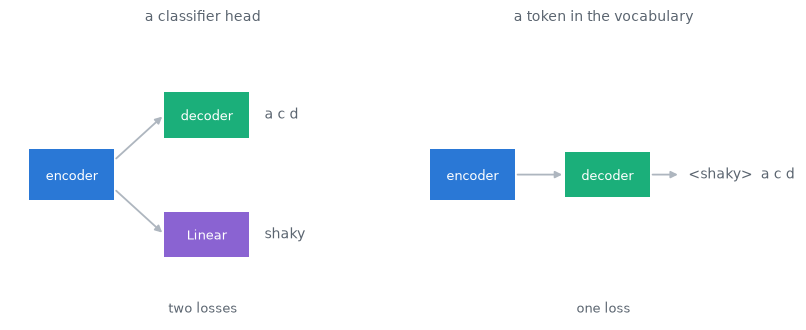

In [1]:
#| label: fig-two-designs
#| fig-cap: The same encoder, two ways to get an emotion out of it. On the left the emotion leaves through a separate head trained by its own loss; on the right it is the first thing the decoder says.
#| fig-alt: Two panels. On the left an encoder feeds both a decoder producing letters and a separate small classifier box producing an emotion, under the words "two losses". On the right the encoder feeds one decoder whose output begins with an emotion token followed by the letters, under the words "one loss".

# Setup, inlined rather than imported so this notebook runs on its own.
# Keep it folded; nothing below it depends on anything outside this file.

import torch.nn as nn
import visualtorch
import matplotlib.pyplot as plt

# --- chart styling -------------------------------------------------------
# Categorical slots of a CVD-validated palette: blue, orange, aqua, purple.
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#8a63d2"]
MUTED, GRID, AXIS = "#5b6570", "#e6e6e3", "#d5d5d1"


def style_axes(ax, xlabel=None, ylabel=None, grid="y"):
    """Strip an axes back to the ink that carries information."""
    if xlabel:
        ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    return ax


def figure(width=7.0, height=4.2, **kw):
    fig, ax = plt.subplots(figsize=(width, height), **kw)
    return fig, ax

# --- visualtorch, configured ---------------------------------------------
# Dropout is hidden: nn.TransformerEncoderLayer exposes its internal Dropout as a
# traceable leaf, every model here builds it with dropout=0.0, and drawing a no-op
# layer says it is part of the architecture when it is not. Uncoloured it also took
# visualtorch's default orange, near enough to MultiheadAttention's to be confusing.
COLOUR_MAP = {
    nn.Linear: {"fill": COLOURS[0]},
    nn.MultiheadAttention: {"fill": COLOURS[1]},
    nn.Embedding: {"fill": COLOURS[3]},
    nn.LayerNorm: {"fill": "#aeb6bf"},
    nn.GELU: {"fill": COLOURS[2]},
    nn.ReLU: {"fill": COLOURS[2]},
    nn.Flatten: {"fill": "#aeb6bf"},
    nn.Dropout: {"fill": "#e6e6e3"},
}
_COMMON = dict(color_map=COLOUR_MAP, connector_fill="#c3c9d0", background_fill="white",
               font_color=MUTED, legend=True, show_dimension=True,
               type_ignore=[nn.Dropout])


def diagram(model, input_shape, style="graph", **overrides):
    """Render `model` as a PIL image in this site's colours.

    `graph` draws real neurons and suits a short stack; `flow` draws volumetric
    blocks whose size tracks the layer's and stays readable on a deep one. `flow`
    reports a 3-D activation as (1, 1, width), losing the sequence length, so its
    shape labels are off. `level_gap=1` keeps a residual connection drawn close to
    the blocks it skips.
    """
    if style == "graph":
        settings = dict(node_size=24, layer_spacing=110, node_spacing=8,
                        ellipsize_after=5, **_COMMON)
    else:
        settings = dict(spacing=26, scale_xy=2.4, max_xy=280, one_dim_orientation="y",
                        level_gap=1, **_COMMON)
        settings["show_dimension"] = False
    settings.update(overrides)
    return visualtorch.render(model, input_shape=input_shape, style=style, **settings)

# --- the log-mel front end -----------------------------------------------
DYNAMIC_RANGE = 8.0      # Whisper clamps the quiet end this far below the loudest


def stft(x, n_fft, hop):
    """Fourier transform of each short overlapping window."""
    window = np.hanning(n_fft + 1)[:-1]
    frames = 1 + (len(x) - n_fft) // hop
    return np.stack([np.fft.rfft(x[i * hop:i * hop + n_fft] * window)
                     for i in range(frames)], axis=1)


def mel_filterbank(rate, n_fft, n_mels):
    """Triangular filters, evenly spaced on the mel scale rather than in hertz."""
    to_mel = lambda f: 2595 * np.log10(1 + f / 700)
    to_hz = lambda m: 700 * (10 ** (m / 2595) - 1)
    edges = to_hz(np.linspace(to_mel(0), to_mel(rate / 2), n_mels + 2))

    # The frequency each FFT bin actually sits at. Rounding the triangle corners to
    # whole bins is the tempting shortcut, and low down the mel bands are narrower
    # than a bin is wide, so several round onto the same corner and come out empty.
    freqs = np.linspace(0, rate / 2, n_fft // 2 + 1)

    bank = np.zeros((n_mels, len(freqs)))
    for m in range(n_mels):
        left, centre, right = edges[m], edges[m + 1], edges[m + 2]
        rising = (freqs - left) / (centre - left)
        falling = (right - freqs) / (right - centre)
        bank[m] = np.maximum(0.0, np.minimum(rising, falling))
        bank[m] *= 2.0 / (right - left)      # equal area, so a wide band cannot shout
    return bank


def log_mel(x, bank, n_fft, hop):
    """A waveform in, a log-mel picture out, time down the rows."""
    power = np.abs(stft(x, n_fft, hop)) ** 2
    picture = np.log10(np.maximum(bank @ power, 1e-10))
    return np.maximum(picture, picture.max() - DYNAMIC_RANGE).T.astype(np.float32)

# --- block diagrams ------------------------------------------------------
FROZEN, EDGE = "#c3ccd6", "#aeb6bf"


def canvas(width=8.4, height=3.4, panels=1, titles=()):
    """One axes per panel, each an empty 0-to-1 grid."""
    fig, axes = plt.subplots(1, panels, figsize=(width, height), squeeze=False)
    axes = list(axes[0])
    for ax, title in zip(axes, list(titles) + [None] * panels):
        if title:
            ax.set_title(title, fontsize=10, color=MUTED, pad=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")
    return (fig, axes[0]) if panels == 1 else (fig, axes)


def block(ax, x, y, w, h, label, colour=None, note=None, text="white", size=9):
    """A labelled rectangle. `note` is a smaller line underneath it."""
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=colour or COLOURS[0],
                               edgecolor="none"))
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", color=text,
            fontsize=size, linespacing=1.4)
    if note:
        ax.text(x + w / 2, y - 0.045, note, ha="center", va="top", color=MUTED,
                fontsize=8)


def arrow(ax, start, end, label=None, size=8):
    """A connector between two points, each an (x, y) pair."""
    ax.annotate("", xy=end, xytext=start,
                arrowprops=dict(arrowstyle="-|>", color=EDGE, linewidth=1.3,
                                shrinkA=2, shrinkB=2))
    if label:
        ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.05, label,
                ha="center", va="bottom", color=MUTED, fontsize=size)


def caption(ax, text, y=0.04, size=9):
    """A line under a panel, for what the panel is arguing."""
    ax.text(0.5, y, text, ha="center", va="center", color=MUTED, fontsize=size)


fig, (left, right) = canvas(width=8.4, height=3.4, panels=2,
                            titles=("a classifier head", "a token in the vocabulary"))

for ax in (left, right):
    block(ax, 0.05, 0.42, 0.22, 0.18, "encoder", COLOURS[0])

# left: the emotion leaves through its own layer, trained by its own loss
arrow(left, (0.27, 0.56), (0.40, 0.72))
arrow(left, (0.27, 0.46), (0.40, 0.30))
block(left, 0.40, 0.64, 0.22, 0.16, "decoder", COLOURS[2])
block(left, 0.40, 0.22, 0.22, 0.16, "Linear", COLOURS[3])
left.text(0.66, 0.72, "a c d", fontsize=10, color=MUTED, va="center")
left.text(0.66, 0.30, "shaky", fontsize=10, color=MUTED, va="center")
caption(left, "two losses")

# right: one output, one loss, the emotion first in the sequence
arrow(right, (0.27, 0.51), (0.40, 0.51))
block(right, 0.40, 0.43, 0.22, 0.16, "decoder", COLOURS[2])
arrow(right, (0.62, 0.51), (0.70, 0.51))
right.text(0.72, 0.51, "<shaky>  a c d", fontsize=10, color=MUTED, va="center")
caption(right, "one loss")

fig.tight_layout()


The appeal isn't elegance for its own sake. Three concrete things follow.

* Adding a seventh emotion is one more row in a table, not a reshaped output layer
  and a checkpoint that no longer loads
* There's one loss instead of two, so nothing to tune between them
* The emotion is emitted first, so every token after it is generated with it in
  context

A classifier head produces its answer off to the side, where the transcription never
sees it. That last point is the real argument for the design. It's also the one
that costs something.

## Measuring Both

Same synthetic speech as the [fine-tuning post](../2026-07-06-fine-tuning-whisper/):
three-letter words where each letter is a tone. Emotion is an acoustic property on
top. `bright` raises the pitch, `shaky` adds a tremolo, `calm` is neither.

Same encoder, same decoder size, same data. The only difference is where the
emotion comes out.

One weakness in that design is worth naming, because it makes the task harder than
I meant it to be. A letter step multiplies the pitch by 1.28 and `bright`
multiplies it by 1.18, so a bright letter lands between its own tone and the next
letter's rather than clearly on its own. The model has to notice that *all three*
tones moved together to tell brightness from a different word. Emotion accuracy
below says it manages, but a cleaner design would have put the emotion somewhere
the letters do not live.

In [2]:
#| warning: false

import numpy as np
import torch
import torch.nn as nn

# Re-running this page must reproduce it, so a result that shifts between runs would let
# the prose and the output disagree. Torch's multithreaded CPU reductions add floats
# in whatever order the threads finish in; over a training loop that compounds into a
# different model. One thread makes the run reproducible.
torch.set_num_threads(1)

RATE, TONE_SECONDS, NOISE = 8000, 0.08, 0.15
ALPHABET = "abcdefgh"
TONES = {c: 300 * 1.28 ** i for i, c in enumerate(ALPHABET)}
EMOTIONS = ["calm", "bright", "shaky"]

rng = np.random.default_rng(0)
WORDS = sorted({"".join(rng.choice(list(ALPHABET), 3)) for _ in range(60)})[:40]

def speak(word, seed, emotion):
    g = np.random.default_rng(seed)
    parts = []
    for c in word:
        t = np.arange(int(RATE * TONE_SECONDS)) / RATE
        f = TONES[c] * (1 + 0.02 * g.normal())
        if emotion == 1:                       # bright: everything a bit higher
            f *= 1.18
        tone = np.sin(2 * np.pi * f * t) + 0.4 * np.sin(4 * np.pi * f * t)
        if emotion == 2:                       # shaky: amplitude wobbles at 22 Hz
            tone = tone * (1 + 0.6 * np.sin(2 * np.pi * 22 * t))
        parts.append(tone * np.hanning(len(t)))
    x = np.concatenate(parts)
    return (x + NOISE * g.normal(size=len(x))).astype(np.float32)

The same spectrogram front end as the other post turns each clip into a picture.

In [3]:
N_FFT, HOP, N_MELS = 256, 64, 32

# The same front end the other post builds from scratch, kept in posts/_audio.py so
# the two cannot drift: overlapping Fourier windows, triangular filters spaced on
# the mel scale, a logarithm, and Whisper's clamp on the quiet end.

BANK = mel_filterbank(RATE, N_FFT, N_MELS)
to_picture = lambda x: log_mel(x, BANK, N_FFT, HOP)

print(f"{N_MELS} mel filters over {BANK.shape[1]} frequency bins, "
      f"{(BANK.sum(1) == 0).sum()} of them empty")

def build(repeats, seed0):
    pictures, words, emotions = [], [], []
    for index, word in enumerate(WORDS):
        for k in range(repeats):
            emotion = (index * 7 + k) % 3
            pictures.append(to_picture(speak(word, seed0 + index * 1000 + k, emotion)))
            words.append(index)
            emotions.append(emotion)
    return torch.from_numpy(np.stack(pictures)), torch.tensor(words), torch.tensor(emotions)

X, W, E = build(12, 0)
X_test, W_test, E_test = build(4, 500_000)
print(f"{len(X)} clips, {len(WORDS)} words x {len(EMOTIONS)} emotions")
print(f"guessing the emotion: {1 / len(EMOTIONS):.3f}")


32 mel filters over 129 frequency bins, 0 of them empty
480 clips, 40 words x 3 emotions
guessing the emotion: 0.333


In [4]:
LETTERS = sorted(set("".join(WORDS)))
EMOTION_TOKENS = [len(LETTERS) + i for i in range(3)]   # the extra vocabulary entries
START, END = len(LETTERS) + 3, len(LETTERS) + 4
VOCAB = len(LETTERS) + 5
DIM, FRAMES = 64, X.shape[1]

# <start> <emotion> l l l <end> — the emotion slot is filled per clip
TARGET = torch.stack([torch.tensor([START, 0] + [LETTERS.index(c) for c in w] + [END])
                      for w in WORDS])

class Model(nn.Module):
    """One encoder, one decoder, and a classifier head that only the head
    variant ever trains."""

    def __init__(self):
        super().__init__()
        self.input = nn.Linear(N_MELS, DIM)
        self.audio_positions = nn.Parameter(torch.randn(1, FRAMES, DIM) * 0.02)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(DIM, 4, 4 * DIM, batch_first=True,
                                       norm_first=True, dropout=0.0), 2)
        self.embed = nn.Embedding(VOCAB, DIM)
        self.text_positions = nn.Parameter(torch.randn(1, 6, DIM) * 0.02)
        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(DIM, 4, 4 * DIM, batch_first=True,
                                       norm_first=True, dropout=0.0), 2)
        self.out = nn.Linear(DIM, VOCAB)
        self.classifier = nn.Linear(DIM, 3)

    def forward(self, picture, tokens):
        memory = self.encoder(self.input(picture) + self.audio_positions)
        h = self.embed(tokens) + self.text_positions[:, :tokens.shape[1]]
        mask = nn.Transformer.generate_square_subsequent_mask(tokens.shape[1])
        return self.out(self.decoder(h, memory, tgt_mask=mask)), self.classifier(memory.mean(1))

One emotion in three by guessing, then, and 40 words to spell. Both numbers get
reported side by side, because the whole question is what the second costs.

Both designs share one model: an encoder over the spectrogram, a decoder, and a
small classifier head hanging off the encoder that only one of them ever trains.

/var/folders/rz/2164hm0x2cv9dcqz41x_4l640000gn/T/ipykernel_91994/638987542.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


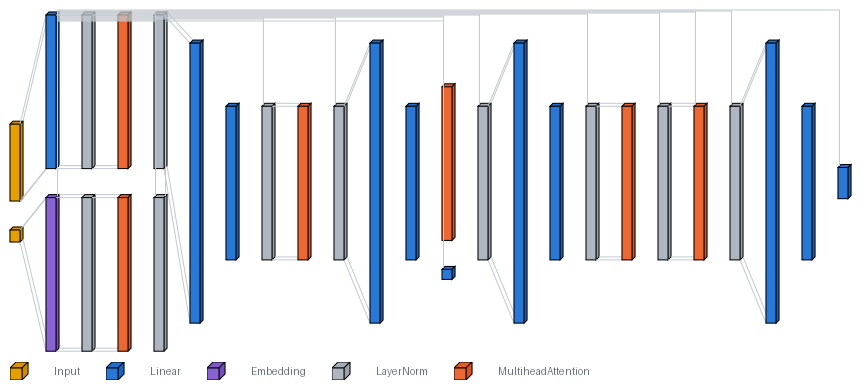

In [5]:
#| label: fig-arch
#| warning: false
#| fig-cap: The shared model. Both designs are this; only the loss differs, and whether the emotion leaves through the decoder or through the small head hanging off the encoder.
#| fig-alt: A diagram with two input streams on the left, the spectrogram above and the token embedding below, running through repeated attention and feed-forward blocks and converging into a single narrow output column on the right.

diagram(Model(), input_shape=((1, X.shape[1], N_MELS), (1, 5)), style="flow",
        input_dtype=(torch.float32, torch.long))

Training them differs only in where the emotion comes out. The token design puts it
in the sequence and uses one cross-entropy over everything. The head design removes
it from the sequence and adds a second loss on the classifier.

Two numbers come back for each: how often the emotion is right, and how often the
word is spelled correctly. Both are averaged over three seeds, with the spread
alongside, because one run of a model this small mostly measures the seed.

In [6]:
#| warning: false

def train(design, seed, epochs=45):
    torch.manual_seed(seed)
    model = Model()
    optimiser = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    generator = torch.Generator().manual_seed(seed)

    for _ in range(epochs):
        perm = torch.randperm(len(X), generator=generator)
        for i in range(0, len(perm) - 64, 64):
            b = perm[i:i + 64]
            target = TARGET[W[b]].clone()
            target[:, 1] = torch.tensor(EMOTION_TOKENS)[E[b]]

            if design == "token":
                logits, _ = model(X[b], target[:, :-1])
                loss = nn.functional.cross_entropy(logits.reshape(-1, VOCAB),
                                                   target[:, 1:].reshape(-1))
            else:
                text = torch.cat([target[:, :1], target[:, 2:]], dim=1)  # emotion removed
                logits, predicted = model(X[b], text[:, :-1])
                loss = (nn.functional.cross_entropy(logits.reshape(-1, VOCAB),
                                                    text[:, 1:].reshape(-1))
                        + nn.functional.cross_entropy(predicted, E[b]))

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
    return model


Scoring has to follow the same split. The token design reads the emotion off the
first thing the decoder emitted; the head design asks the classifier. Both then
check the three letters.

In [7]:
@torch.no_grad()
def evaluate(model, design):
    tokens = torch.full((len(X_test), 1), START)
    steps = 4 if design == "token" else 3
    for _ in range(steps):
        tokens = torch.cat([tokens, model(X_test, tokens)[0][:, -1].argmax(-1, keepdim=True)], 1)

    if design == "token":
        emitted = tokens[:, 1]
        emotion = torch.tensor([EMOTION_TOKENS.index(i) if i in EMOTION_TOKENS else -1
                                for i in emitted.tolist()])
        word = (tokens[:, 2:5] == TARGET[W_test][:, 2:5]).all(1)
    else:
        emotion = model(X_test, tokens[:, :1])[1].argmax(1)
        word = (tokens[:, 1:4] == TARGET[W_test][:, 2:5]).all(1)

    return (emotion == E_test).float().mean().item(), word.float().mean().item()


Three seeds each, because one run of a model this small says more about the seed
than about the design.

In [8]:
# Three seeds, because one run of a model this small says more about the seed than
# about the design. The spread is reported next to the mean for the same reason.
SEEDS = (0, 1, 2)
results = {design: [evaluate(train(design, s), design) for s in SEEDS]
           for design in ("head", "token")}

def cell(values):
    return f"{sum(values) / len(values):.3f} ({min(values):.3f}-{max(values):.3f})"

# Built as one string and printed once, so the table arrives as a single block
rows = [f"{'design':>26} {'emotion':>21} {'word':>21}"]
for design, name in (("head", "a classifier head"), ("token", "a token in the vocabulary")):
    runs = results[design]
    rows.append(f"{name:>26} {cell([e for e, _ in runs]):>21} "
                f"{cell([w for _, w in runs]):>21}")
rows.append(f"{'':>26} {'mean (min-max) over ' + str(len(SEEDS)) + ' seeds':>21}")
print("\n".join(rows))

/var/folders/rz/2164hm0x2cv9dcqz41x_4l640000gn/T/ipykernel_91994/638987542.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


/var/folders/rz/2164hm0x2cv9dcqz41x_4l640000gn/T/ipykernel_91994/638987542.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


                    design               emotion                  word
         a classifier head   0.925 (0.837-0.988)   0.969 (0.950-0.981)
 a token in the vocabulary   0.812 (0.688-0.931)   0.958 (0.950-0.969)
                           mean (min-max) over 3 seeds


Read the ranges in brackets before the means in front of them.

## Conclusion

This experiment does not separate the two designs. The ranges overlap on both
measures, and on a test set this size a few clips moves a mean further than the
gap between them. Anyone reporting one seed here would have got a clean-looking
result and it would have meant nothing.

What is not a measurement is where the work lands. A two-layer decoder in the token
design has to produce the emotion *and* spell the word; in the head design it only
spells, and the emotion comes off the encoder through its own layer. The emotion is
in the encoder either way, so where you attach the readout does not change what
there is to read — it changes how much the decoder is carrying.

Whatever that costs, it is a small-model concern. Whisper's decoder is far larger
and already emits several control tokens before it writes anything, so one more
costs it nothing noticeable. The trap would have been to run this at one size, watch
one design lose, and call the design worse when what I had measured was my own
decoder being too small.

So the architectural argument stands on its own terms rather than on the numbers: a
vocabulary entry instead of a reshaped head, one loss instead of two, and an emotion
the transcription can actually see.

The full project is
[on GitHub](https://github.com/RoshBeed/ai-residency/tree/main/services/speech-emotion-recognition).
